<a href="https://colab.research.google.com/github/NishiChauhan26/Olympic-Medal-Prediction-ML/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!find /content/drive -name "teams.csv"


find: ‘/content/drive’: No such file or directory


In [15]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [16]:
!ls /content/drive/MyDrive


'Category 1.gsheet'		       Nishi_resume.pdf
'Category 2.gsheet'		       NISHI_Resume.pdf
'Category 3.gsheet'		       Photo.jpg
 Certificates			       Result1.pdf
'Colab Notebooks'		       Result.pdf
 CUETAdmitCard-233510035013_copy.pdf   teams.csv
 Heart_Disease_Prediction.csv	      'Untitled spreadsheet.gsheet'
 housing.csv			      'Эстетичные обои.jpeg'
 Laptop


In [17]:
import pandas as pd


In [18]:
!find /content/drive/MyDrive -name "teams.csv"


/content/drive/MyDrive/teams.csv


In [19]:
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [20]:
teams = pd.read_csv("teams.csv")

In [21]:
teams

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3


In [22]:
teams = teams[["team", "country", "year", "athletes", "age", "prev_medals", "medals"]]

In [23]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [24]:
corr_matrix = teams.corr(numeric_only=True)
corr_matrix["medals"]

,medals
year,-0.021603
athletes,0.840817
age,0.025096
prev_medals,0.920048
medals,1.000000


In [25]:
import seaborn as sns

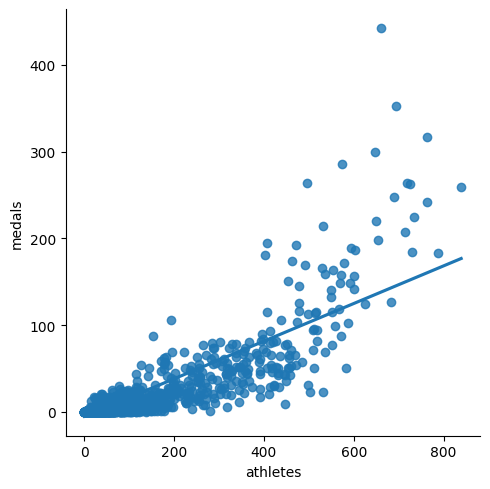

In [26]:
sns.lmplot(x="athletes", y="medals", data = teams, fit_reg = True, ci=None)

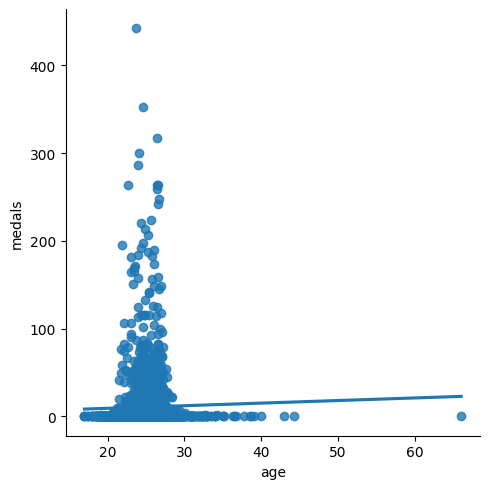

In [27]:
sns.lmplot(x="age", y="medals",data =teams, fit_reg =True, ci = None)

<Axes: ylabel='Frequency'>

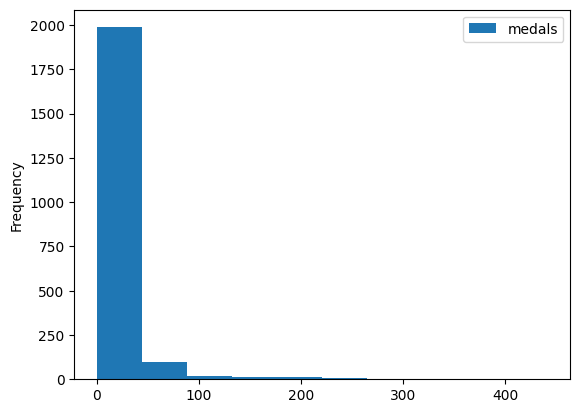

In [28]:
teams.plot.hist(y="medals")

In [29]:
teams[teams.isnull().any(axis=1)]

,team,country,year,athletes,age,prev_medals,medals
19,ALB,Albania,1992,9,25.3,NaN,0
26,ALG,Algeria,1964,7,26.0,NaN,0
39,AND,Andorra,1976,3,28.3,NaN,0
50,ANG,Angola,1980,17,17.4,NaN,0
59,ANT,Antigua and Barbuda,1976,17,23.2,NaN,0
...,...,...,...,...,...,...,...
2092,VIN,Saint Vincent and the Grenadines,1988,6,20.5,NaN,0
2103,YAR,North Yemen,1984,3,27.7,NaN,0
2105,YEM,Yemen,1992,8,19.6,NaN,0
2112,YMD,South Yemen,1988,5,23.6,NaN,0


In [30]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [31]:
teams = teams.dropna()

In [32]:
teams["athletes_per_medal"] = teams["athletes"] / (teams["prev_medals"] + 1)

teams["medal_growth"] = teams["prev_medals"] / (teams["age"] + 1)

teams["athlete_age_interaction"] = teams["athletes"] * teams["age"]

/tmp/ipykernel_2130/3402873529.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teams["athletes_per_medal"] = teams["athletes"] / (teams["prev_medals"] + 1)
/tmp/ipykernel_2130/3402873529.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  teams["medal_growth"] = teams["prev_medals"] / (teams["age"] + 1)
/tmp/ipykernel_2130/3402873529.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

In [33]:
train = teams[teams["year"] < 2012].copy()
test = teams[teams["year"] >=2012].copy()

In [34]:
train.shape

(1609, 10)

In [35]:
test.shape

(405, 10)

In [36]:
from sklearn.ensemble import RandomForestRegressor

reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

In [37]:
predictors = [
    "athletes",
    "age",
    "prev_medals",
    "athletes_per_medal",
    "medal_growth",
    "athlete_age_interaction"
]
target = "medals"

In [38]:
reg.fit(train[predictors], train[target])

RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=300,
                      random_state=42)

In [39]:
predictions = reg.predict(test[predictors])

In [40]:
# predictions:- this will give predictions in decimal form as well as negative number and the medals cannnot be in such a form
test["predictions"] = predictions

In [41]:
test

,team,country,year,athletes,age,prev_medals,medals,athletes_per_medal,medal_growth,athlete_age_interaction,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,3.0,0.038760,148.8,0.235940
7,AFG,Afghanistan,2016,3,24.7,1.0,0,1.5,0.038911,74.1,0.297639
24,ALB,Albania,2012,10,25.7,0.0,0,10.0,0.000000,257.0,0.034889
25,ALB,Albania,2016,6,23.7,0.0,0,6.0,0.000000,142.2,0.047923
37,ALG,Algeria,2012,39,24.8,2.0,1,13.0,0.077519,967.2,2.349010
...,...,...,...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,3.0,0.000000,57.9,0.016269
2131,ZAM,Zambia,2012,7,22.6,0.0,0,7.0,0.000000,158.2,0.038613
2132,ZAM,Zambia,2016,7,24.1,0.0,0,7.0,0.000000,168.7,0.045336
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,1.8,0.141343,245.7,2.333217


In [42]:
test.loc[test["predictions"] < 0, "predictions"] = 0

In [43]:
test["predictions"] = test["predictions"].round()

In [44]:
test

,team,country,year,athletes,age,prev_medals,medals,athletes_per_medal,medal_growth,athlete_age_interaction,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,3.0,0.038760,148.8,0.0
7,AFG,Afghanistan,2016,3,24.7,1.0,0,1.5,0.038911,74.1,0.0
24,ALB,Albania,2012,10,25.7,0.0,0,10.0,0.000000,257.0,0.0
25,ALB,Albania,2016,6,23.7,0.0,0,6.0,0.000000,142.2,0.0
37,ALG,Algeria,2012,39,24.8,2.0,1,13.0,0.077519,967.2,2.0
...,...,...,...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,3.0,0.000000,57.9,0.0
2131,ZAM,Zambia,2012,7,22.6,0.0,0,7.0,0.000000,158.2,0.0
2132,ZAM,Zambia,2016,7,24.1,0.0,0,7.0,0.000000,168.7,0.0
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,1.8,0.141343,245.7,2.0


In [45]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    test["medals"],
    test["predictions"]
)

r2 = r2_score(
    test["medals"],
    test["predictions"]
)

print("MAE =", mae)
print("R² =", r2)

MAE = 3.4419753086419753
R² = 0.8898459148726624


<Axes: >

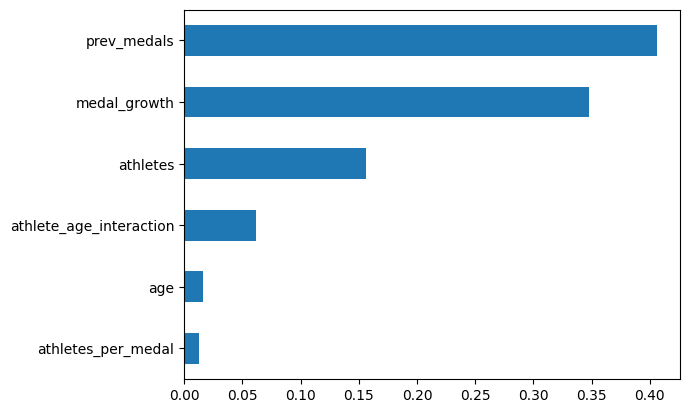

In [46]:
importance = pd.Series(
    reg.feature_importances_,
    index=predictors
)

importance.sort_values().plot.barh()

In [47]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    reg,
    teams[predictors],
    teams["medals"],
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Average MAE:", -scores.mean())

Average MAE: 4.448228402733011


In [48]:
test[test["team"] == "USA"]

,team,country,year,athletes,age,prev_medals,medals,athletes_per_medal,medal_growth,athlete_age_interaction,predictions
2053,USA,United States,2012,689,26.7,317.0,248,2.166667,11.444043,18396.3,300.0
2054,USA,United States,2016,719,26.4,248.0,264,2.887550,9.051095,18981.6,264.0


In [49]:
test[test["team"]=="IND"]

,team,country,year,athletes,age,prev_medals,medals,athletes_per_medal,medal_growth,athlete_age_interaction,predictions
907,IND,India,2012,95,26.0,3.0,6,23.750000,0.111111,2470.0,4.0
908,IND,India,2016,130,26.1,6.0,2,18.571429,0.221402,3393.0,7.0


In [50]:
errors = (test["medals"]- test["predictions"]).abs()

In [51]:
error_by_team = errors.groupby(test["team"]).mean()

In [52]:
error_by_team

,0
team,
AFG,0.5
ALB,0.0
ALG,1.0
AND,0.0
ANG,0.5
...,...
VIE,2.5
VIN,0.0
YEM,0.0


In [53]:
medals_by_team = test["medals"].groupby(test["team"]).mean()

In [54]:
error_ratio = error_by_team / medals_by_team

In [55]:
error_ratio

,0
team,
AFG,1.000000
ALB,NaN
ALG,0.666667
AND,NaN
ANG,inf
...,...
VIE,2.500000
VIN,NaN
YEM,NaN


In [56]:
# To take the values that are not missing
error_ratio[~pd.isnull(error_ratio)]

,0
team,
AFG,1.000000
ALG,0.666667
ANG,inf
ARG,0.926829
ARM,0.285714
...,...
USA,0.101562
UZB,0.687500
VEN,0.500000


In [57]:
# to clear the infinite value
import numpy as np
error_ratio = error_ratio[np.isfinite(error_ratio)]

In [58]:
error_ratio

,0
team,
AFG,1.000000
ALG,0.666667
ARG,0.926829
ARM,0.285714
AUS,0.295918
...,...
UKR,0.804878
USA,0.101562
UZB,0.687500


<Axes: ylabel='Frequency'>

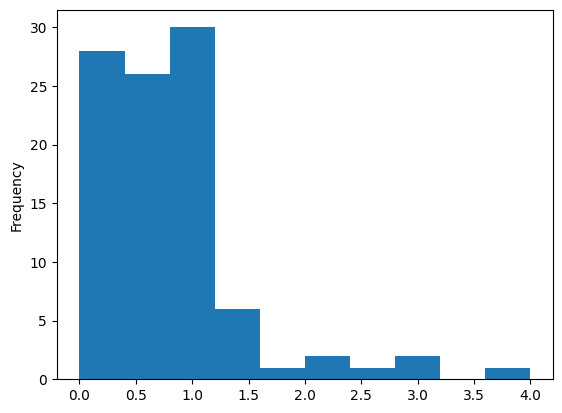

In [59]:
error_ratio.plot.hist()

In [60]:
error_ratio.sort_values()

,0
team,
EGY,0.000000
SLO,0.000000
TUN,0.000000
ETH,0.066667
CAN,0.072581
...,...
UGA,2.000000
VIE,2.500000
AUT,3.000000
